# First Building the time based conceder from lecture slides.

In [1]:
from negmas.preferences import LinearAdditiveUtilityFunction as LUFun
from negmas.preferences.value_fun import LinearFun, IdentityFun, AffineFun
from negmas import SAOMechanism, TimeBasedConcedingNegotiator, MappingUtilityFunction, make_issue, ResponseType

from aadi.time_based_agent import TimeBasedAspirationConceder, UniqueArgmaxTimeBasedConceder, AdaptiveUniqueArgmaxConceder, NaiveBayesianTimeBasedNegotiator

## Scenario Issues

Agents will be injected

In [2]:
from negmas import *
from negmas.sao import SAOMechanism, SAONegotiator, ResponseType

# 1. Define Issues
# issues = [
#     make_issue(name="price", values=list(range(10, 31))),       # 10..30
#     make_issue(name="quantity", values=list(range(1, 21))),     # 1..20
#     make_issue(name="delivery_time", values=list(range(1, 16))) # 1..15
# ]

# Expanded issues to provide more "fuel" for the Boulware strategy
issues = [
    make_issue(name="price", values=list(range(10, 101))),      # 10..100 (91 values)
    make_issue(name="quantity", values=list(range(1, 51))),    # 1..50 (50 values)
    make_issue(name="delivery_time", values=list(range(1, 31))) # 1..30 (30 values)
]
# Total outcomes: 91 * 50 * 30 = 136,500 (vs 6,300 previously)

# 2. Normalization Helper
class Normalize:
    def __init__(self, min_value, max_value):
        self.min = min_value
        self.max = max_value
    def __call__(self, value):
        return (value - self.min) / (self.max - self.min)

# 3. Define Opposing Utility Functions
# Your agent wants high values
ufun_self = LUFun(
    issues=issues,
    values=[Normalize(10, 30), Normalize(1, 20), Normalize(1, 15)],
    weights=[0.5, 0.3, 0.2]
)

# The opponent wants low values
ufun_opp = LUFun(
    issues=issues,
    values=[Normalize(30, 10), Normalize(20, 1), Normalize(15, 1)],
    weights=[0.5, 0.3, 0.2]
)



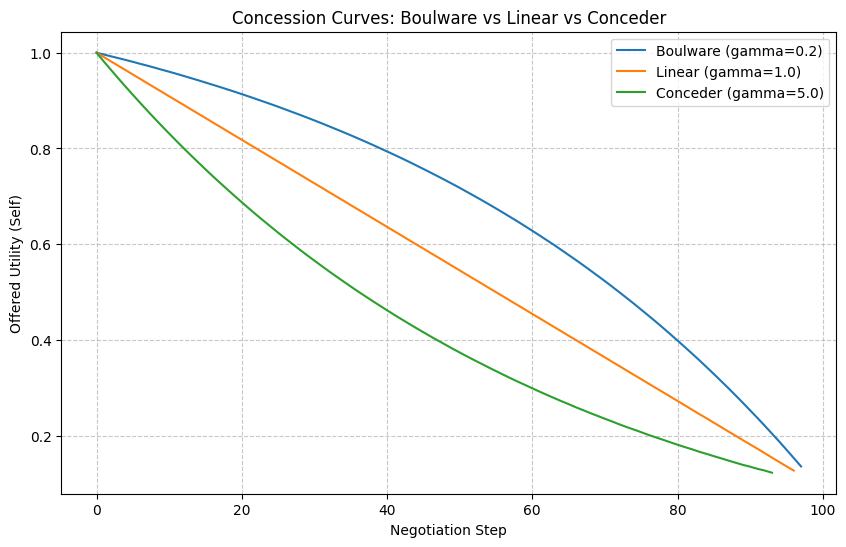

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Let us construct our agents : label to agent dict
agents = {
    "Boulware (gamma=0.2)": UniqueArgmaxTimeBasedConceder(name="Boulware", gamma=0.2),
    "Linear (gamma=1.0)": UniqueArgmaxTimeBasedConceder(name="Linear", gamma=1.0),
    "Conceder (gamma=5.0)": UniqueArgmaxTimeBasedConceder(name="Conceder", gamma=5.0)
}

# 5. Run and Plot
def run_bilaterally_against_hardliner():
    plt.figure(figsize=(10, 6))
    for label, agent in agents.items():
        # 100 steps to show a detailed curve
        session = SAOMechanism(issues=issues, n_steps=100)
        # Add the specific strategy
        me = agent
        session.add(me, ufun=ufun_self)
        # Add a "Hardliner" opponent to ensure the negotiation doesn't end too early
        # This allows us to see the full concession curve
        opp = UniqueArgmaxTimeBasedConceder(name="Opponent", gamma=0.01, beta=0.9)
        # opp = TimeBasedConcedingNegotiator(name="Opponent", offering_curve="boulware") # boulware is more hardheaded...
        session.add(opp, ufun=ufun_opp)
        session.run()
        # Plot the utility history tracked inside the agent
        plt.plot(me.utility_history, label=label)
    plt.title("Concession Curves: Boulware vs Linear vs Conceder")
    plt.ylabel("Offered Utility (Self)")
    plt.xlabel("Negotiation Step")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Execute
run_bilaterally_against_hardliner()

# Adaptive beta selection in the bidding

Match vs Negmas_Linear: Agreement
Match vs Negmas_Boulware: Agreement
Match vs Negmas_Conceder: Agreement


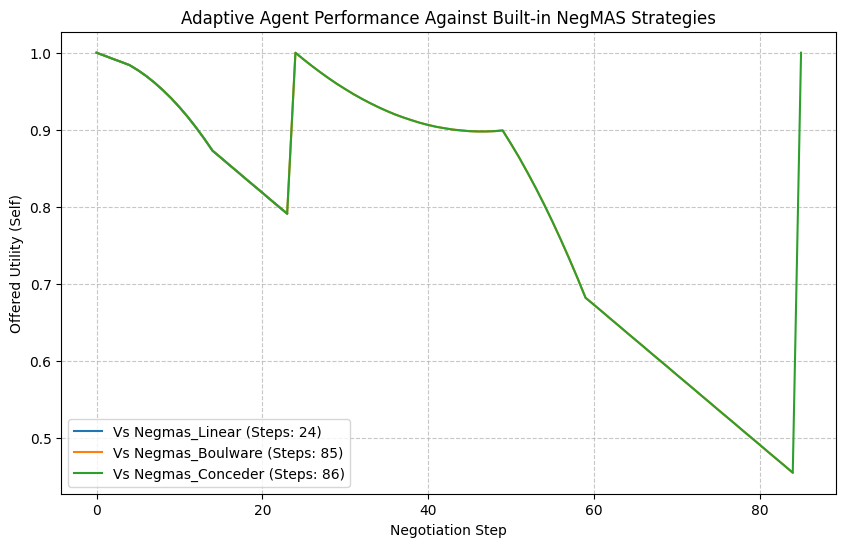

In [4]:
def run_adaptive_vs_builtins():
    # Define our adaptive agent
    adaptive_agent = AdaptiveUniqueArgmaxConceder(name="AdaptiveAgent", gamma=1.0, beta_start=0.6)
    
    # Define built-in opponents
    opponents = [
        TimeBasedConcedingNegotiator(name="Negmas_Linear", offering_curve="linear"),
        TimeBasedConcedingNegotiator(name="Negmas_Boulware", offering_curve="boulware"),
        TimeBasedConcedingNegotiator(name="Negmas_Conceder", offering_curve="conceder")
    ]

    plt.figure(figsize=(10, 6))

    for opp in opponents:
        session = SAOMechanism(issues=issues, n_steps=100)
        session.add(adaptive_agent, ufun=ufun_self)
        session.add(opp, ufun=ufun_opp)
        
        result = session.run()
        
        label = f"Vs {opp.name} (Steps: {len(adaptive_agent.utility_history)})"
        plt.plot(adaptive_agent.utility_history, label=label)
        print(f"Match vs {opp.name}: {'Agreement' if result.agreement else 'No Agreement'}")

    plt.title("Adaptive Agent Performance Against Built-in NegMAS Strategies")
    plt.ylabel("Offered Utility (Self)")
    plt.xlabel("Negotiation Step")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Execute
run_adaptive_vs_builtins()

# Opponent Modelling

Now lets build a opponent model into this purely time base bidding (B) agents

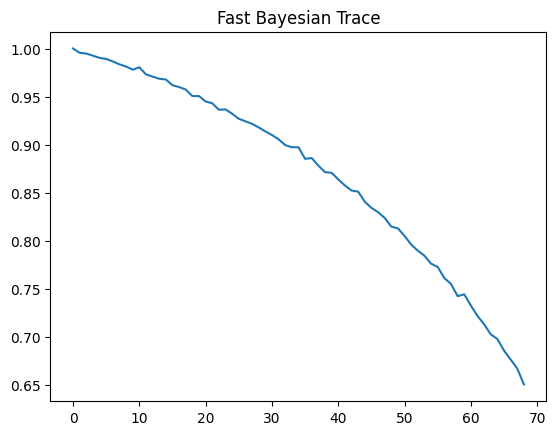

In [5]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from negmas import *
from negmas.sao import SAOMechanism, SAONegotiator, ResponseType, TimeBasedConcedingNegotiator

# Evaluation
def run_test():
    issues = [make_issue((10, 30), "p"), make_issue((1, 20), "q"), make_issue((1, 15), "d")]
    u_self = LUFun(issues=issues, values=[Normalize(10,30), Normalize(1,20), Normalize(1,15)])
    u_opp = LUFun(issues=issues, values=[Normalize(30,10), Normalize(20,1), Normalize(15,1)])

    session = SAOMechanism(issues=issues, n_steps=100)
    agent = TimeBasedAspirationConceder(alpha=1.0, beta=0.2, gamma=0.1)
    session.add(agent, ufun=u_self)
    session.add(TimeBasedConcedingNegotiator(offering_curve="boulware"), ufun=u_opp)
    
    session.run()
    plt.plot(agent.utility_history)
    plt.title("Fast Bayesian Trace")
    plt.show()

run_test()

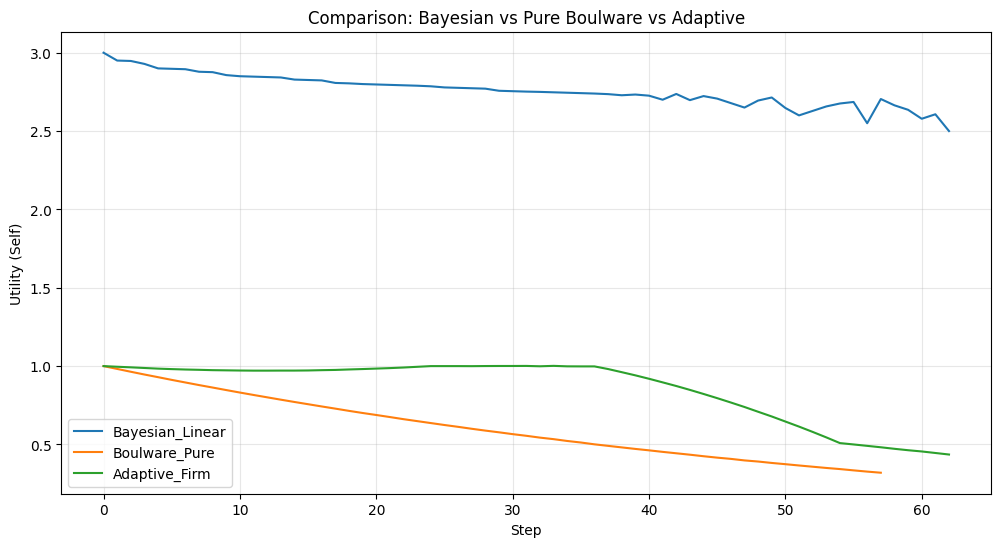

In [6]:
import matplotlib.pyplot as plt

def run_final_comparison():
    # Setup
    issues = [make_issue((10, 30), "price"), make_issue((1, 20), "qty"), make_issue((1, 15), "time")]
    u_self = LUFun(issues=issues, values=[Normalize(10,30), Normalize(1,20), Normalize(1,15)])
    u_opp = LUFun(issues=issues, values=[Normalize(30,10), Normalize(20,1), Normalize(15,1)])

    # 1. Define the test subjects
    test_agents = [
        NaiveBayesianTimeBasedNegotiator(name="Bayesian_Linear", gamma=1.0),
        UniqueArgmaxTimeBasedConceder(name="Boulware_Pure", gamma=5.0),
        AdaptiveUniqueArgmaxConceder(name="Adaptive_Firm", gamma=1.0, beta_start=0.6)
    ]

    plt.figure(figsize=(12, 6))

    for agent in test_agents:
        session = SAOMechanism(issues=issues, n_steps=100)
        session.add(agent, ufun=u_self)
        # Standard opponent to test against
        opponent = TimeBasedConcedingNegotiator(name="Opponent", offering_curve="boulware")
        session.add(opponent, ufun=u_opp)
        
        session.run()
        plt.plot(agent.utility_history, label=agent.name)

    
    plt.title("Comparison: Bayesian vs Pure Boulware vs Adaptive")
    plt.ylabel("Utility (Self)")
    plt.xlabel("Step")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

run_final_comparison()